regiones y fronteras

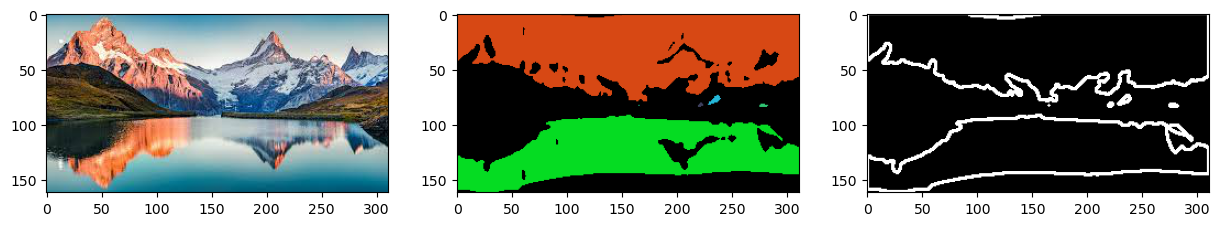

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img=cv2.imread('imagen2.jpg')
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
#combino tecnicas para mejorar la tecnica
blur=cv2.GaussianBlur(gray,(7,7),0)
_,binary=cv2.threshold(blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
#encontramos las regiones
num_l,label=cv2.connectedComponents(binary)
#identificamos por colores
color=np.random.randint(0,255,size=(num_l,3),dtype=np.uint8)
#fondo negro
color[0]=[0,0,0]
colorear=color[label]
#encontrar fronteras
contorno,_=cv2.findContours(binary,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
contorno_fin=cv2.drawContours(np.zeros_like(gray),contorno,-1,255,2)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.subplot(1,3,2)
plt.imshow(colorear)
plt.subplot(1,3,3)
plt.imshow(contorno_fin,cmap='gray')
plt.show()

Conteos

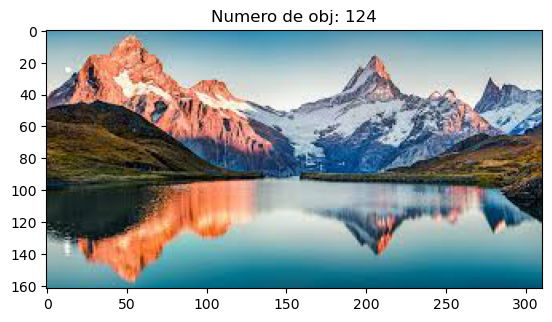

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _,binary=cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

    e_img=measure.label(binary,connectivity=2)#2=conectividad es 4, 1=conectividad es 8
    num_adj=np.max(e_img)
    return num_adj

imagen=cv2.imread('imagen2.jpg')
conteo=contar_elementos(imagen)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.title(f'Numero de obj: {conteo}')
plt.show()

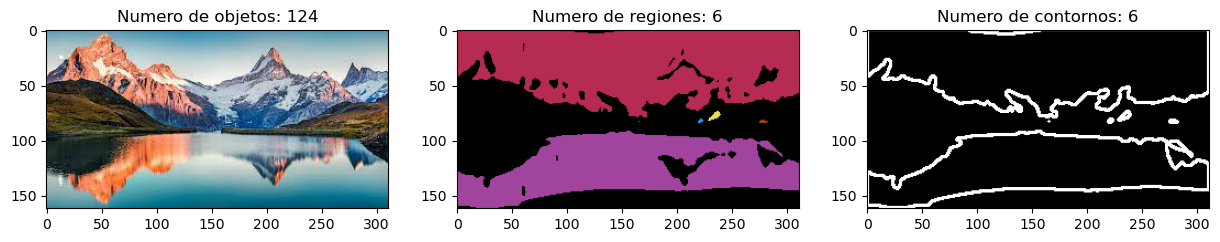

Regiones: 
 (np.uint8(181), np.uint8(43), np.uint8(81)): 18127px
(np.uint8(241), np.uint8(222), np.uint8(83)): 49px
(np.uint8(27), np.uint8(151), np.uint8(243)): 14px
(np.uint8(32), np.uint8(155), np.uint8(147)): 1px
(np.uint8(160), np.uint8(62), np.uint8(22)): 19px
(np.uint8(161), np.uint8(68), np.uint8(157)): 12309px


In [67]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img=cv2.imread('imagen2.jpg')
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
def contar_elementos(img):
    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _,binary=cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

    e_img=measure.label(binary,connectivity=2)#2=conectividad es 4, 1=conectividad es 8
    num_adj=np.max(e_img)
    return num_adj

#combino tecnicas para mejorar la tecnica
blur=cv2.GaussianBlur(gray,(7,7),0)
_,binary=cv2.threshold(blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
#encontramos las regiones
num_l,label=cv2.connectedComponents(binary)
#identificamos por colores
color=np.random.randint(0,255,size=(num_l,3),dtype=np.uint8)
#fondo negro
color[0]=[0,0,0]
colorear=color[label]
contarcolor=num_l-1
texto = []

for i in range(1, num_l):
    pixeles = np.sum(label == i)
    col = tuple(color[i])
    texto.append(f'{col}: {pixeles}px')

texto = "\n".join(texto)
#encontrar fronteras
contorno,_=cv2.findContours(binary,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
contorno_fin=cv2.drawContours(np.zeros_like(gray),contorno,-1,255,2)
num_contornos = len(contorno)

conteo=contar_elementos(img)
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title(f'Numero de objetos: {conteo}')
plt.subplot(1,3,2)
plt.imshow(colorear)
plt.title(f'Numero de regiones: {contarcolor}')
plt.subplot(1,3,3)
plt.imshow(contorno_fin,cmap='gray')
plt.title(f'Numero de contornos: {num_contornos}')
plt.show()
print(f'Regiones: \n {texto}')